<a href="https://colab.research.google.com/github/ritika9090/Ritika-d-creative-work-space/blob/main/Carbon2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn tensorflow

In [ ]:
import pandas as pd

file_name = '/content/company_esg_financial_dataset (1).csv'

if file_name.endswith('.xlsx'):
    df = pd.read_excel(file_name)
else:
    df = pd.read_csv(file_name)

df.head()

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8


In [ ]:
df.shape

(11000, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CompanyID          11000 non-null  int64  
 1   CompanyName        11000 non-null  object 
 2   Industry           11000 non-null  object 
 3   Region             11000 non-null  object 
 4   Year               11000 non-null  int64  
 5   Revenue            11000 non-null  float64
 6   ProfitMargin       11000 non-null  float64
 7   MarketCap          11000 non-null  float64
 8   GrowthRate         10000 non-null  float64
 9   ESG_Overall        11000 non-null  float64
 10  ESG_Environmental  11000 non-null  float64
 11  ESG_Social         11000 non-null  float64
 12  ESG_Governance     11000 non-null  float64
 13  CarbonEmissions    11000 non-null  float64
 14  WaterUsage         11000 non-null  float64
 15  EnergyConsumption  11000 non-null  float64
dtypes: float64(11), int64(

In [ ]:
df.describe()

,CompanyID,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,10000.000000,11000.000000,11000.000000,11000.000000,11000.000000,1.100000e+04,1.100000e+04,1.100000e+04
mean,500.500000,2020.000000,4670.850591,10.900455,13380.622236,4.830370,54.615273,56.416991,55.660582,51.767655,1.271462e+06,5.600442e+05,1.165839e+07
std,288.688113,3.162421,9969.954369,8.758711,39922.870373,9.424787,15.893937,26.767233,23.356152,25.323370,5.067760e+06,1.565686e+06,5.095836e+07
min,1.000000,2015.000000,35.900000,-20.000000,1.800000,-36.000000,6.300000,0.000000,0.000000,0.000000,2.042200e+03,1.021100e+03,5.105500e+03
25%,250.750000,2017.000000,938.775000,5.300000,1098.525000,-1.325000,44.100000,34.700000,37.600000,30.775000,1.228530e+05,6.488467e+04,3.069161e+05
50%,500.500000,2020.000000,1902.300000,10.500000,3096.450000,4.900000,54.600000,55.600000,55.150000,52.100000,2.920734e+05,2.038805e+05,1.221745e+06
75%,750.250000,2023.000000,4342.625000,16.300000,9995.500000,11.000000,65.600000,79.000000,73.800000,73.000000,7.407311e+05,5.251880e+05,5.616437e+06
max,1000.000000,2025.000000,180810.400000,50.000000,865271.700000,38.000000,98.800000,100.000000,100.000000,100.000000,1.741047e+08,5.223142e+07,1.741047e+09


In [ ]:
df = df.fillna(method='ffill')
df = df.fillna(method='bfill')
df = df.dropna()
df.shape

/tmp/ipython-input-3469315969.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
/tmp/ipython-input-3469315969.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')


(11000, 16)

In [ ]:
import numpy as np

numeric_cols = df.select_dtypes(include=np.number).columns
target_column = numeric_cols[-1]

target_column

'EnergyConsumption'

In [ ]:
import numpy as np

numeric_cols = df.select_dtypes(include=np.number).columns
target_column = numeric_cols[-1]

target_column

'EnergyConsumption'

In [ ]:
X = df.drop(columns=[target_column])
y = df[target_column]

In [ ]:
X = df.drop(columns=[target_column])
y = df[target_column]
X = pd.get_dummies(X, drop_first=True)
X.head()

,CompanyID,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,...,Industry_Retail,Industry_Technology,Industry_Transportation,Industry_Utilities,Region_Asia,Region_Europe,Region_Latin America,Region_Middle East,Region_North America,Region_Oceania
0,1,2015,459.2,6.0,337.5,3.2,57.0,60.7,33.5,76.8,...,True,False,False,False,False,False,True,False,False,False
1,1,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,...,True,False,False,False,False,False,True,False,False,False
2,1,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,...,True,False,False,False,False,False,True,False,False,False
3,1,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,...,True,False,False,False,False,False,True,False,False,False
4,1,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,...,True,False,False,False,False,False,True,False,False,False


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
split_index = int(len(X_scaled) * 0.8)

X_train = X_scaled[:split_index]
X_test = X_scaled[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

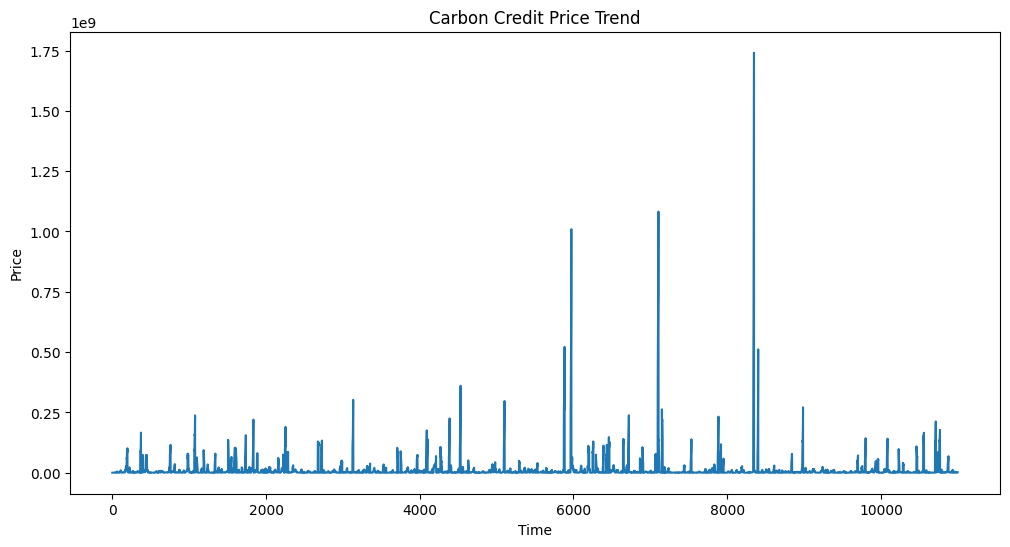

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y.values)
plt.title("Carbon Credit Price Trend")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

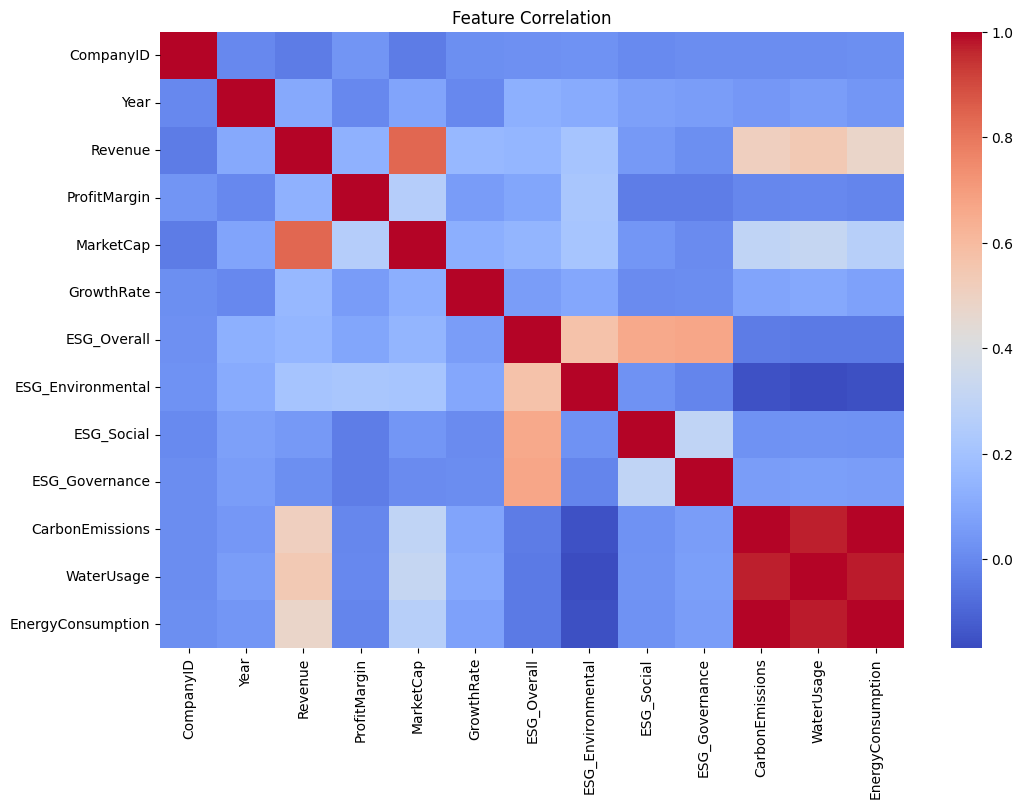

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

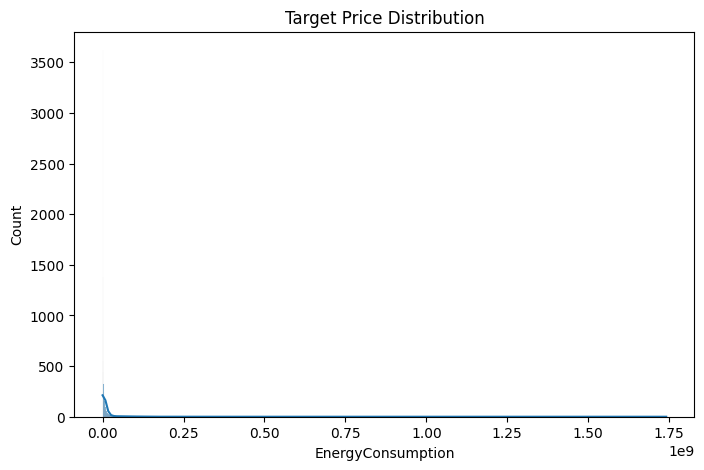

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(y, kde=True)
plt.title("Target Price Distribution")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

mae, rmse, r2

(146666.50721213158, np.float64(1751434.3416640817), 0.9948586913646434)

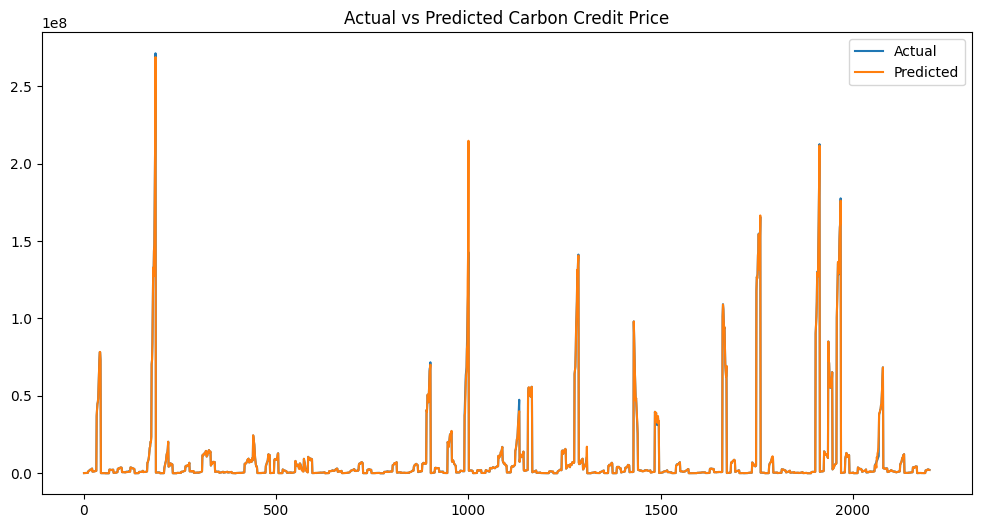

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Carbon Credit Price")
plt.show()

In [ ]:
signals = []

for i in range(1, len(predictions)):
    if predictions[i] > predictions[i-1] * 1.02:
        signals.append("BUY")
    elif predictions[i] < predictions[i-1] * 0.98:
        signals.append("SELL")
    else:
        signals.append("HOLD")

signals[:20]

['HOLD',
 'HOLD',
 'BUY',
 'BUY',
 'BUY',
 'BUY',
 'HOLD',
 'HOLD',
 'BUY',
 'BUY',
 'BUY',
 'BUY',
 'BUY',
 'BUY',
 'BUY',
 'BUY',
 'SELL',
 'HOLD',
 'BUY',
 'BUY']

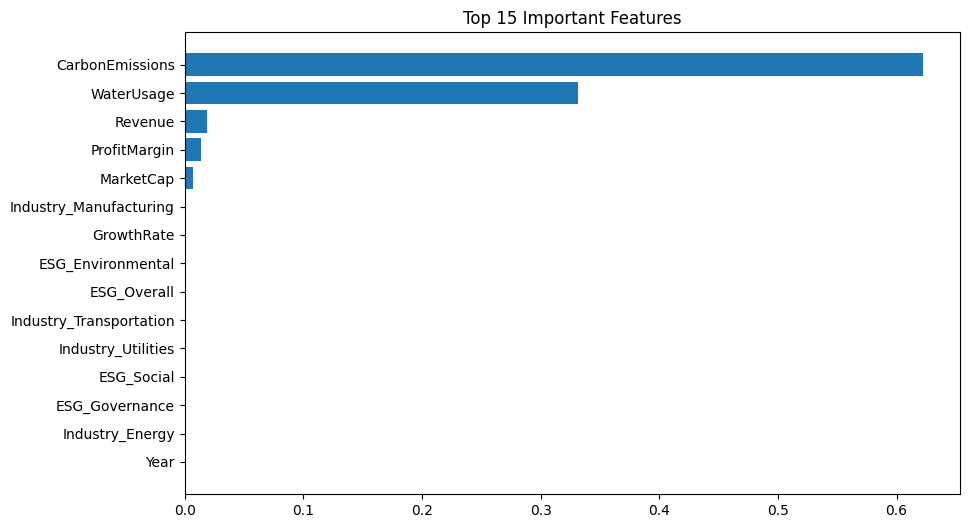

In [ ]:
import numpy as np

importance = model.feature_importances_
feature_names = X.columns

indices = np.argsort(importance)[-15:]

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importance[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.title("Top 15 Important Features")
plt.show()

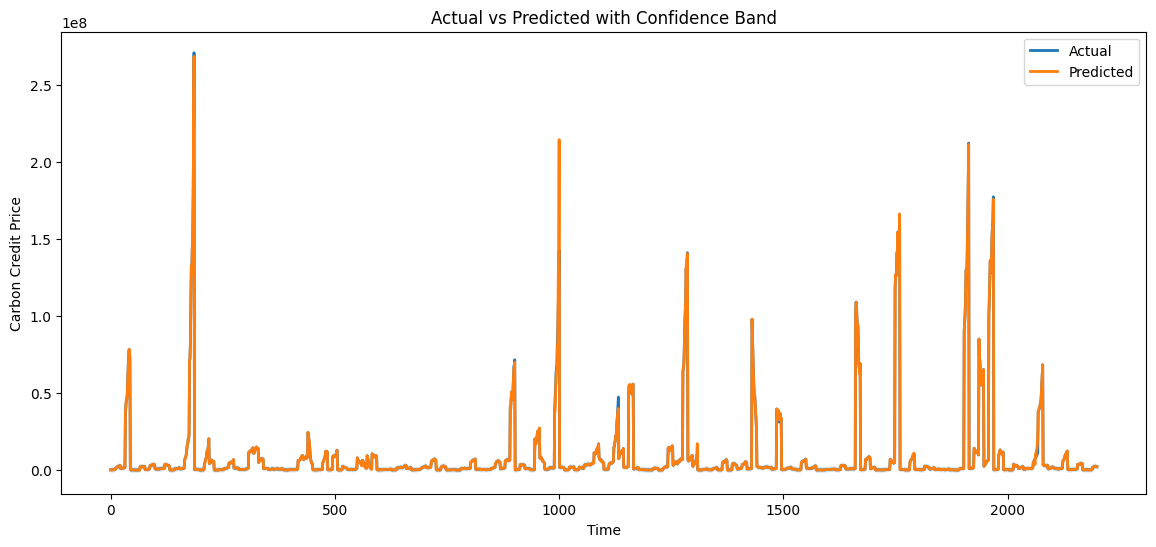

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

residuals = y_test.values - predictions
std_dev = np.std(residuals)

plt.figure(figsize=(14,6))
plt.plot(y_test.values, label="Actual", linewidth=2)
plt.plot(predictions, label="Predicted", linewidth=2)

upper_band = predictions + std_dev
lower_band = predictions - std_dev

plt.fill_between(range(len(predictions)), lower_band, upper_band, alpha=0.2)

plt.legend()
plt.title("Actual vs Predicted with Confidence Band")
plt.xlabel("Time")
plt.ylabel("Carbon Credit Price")
plt.show()

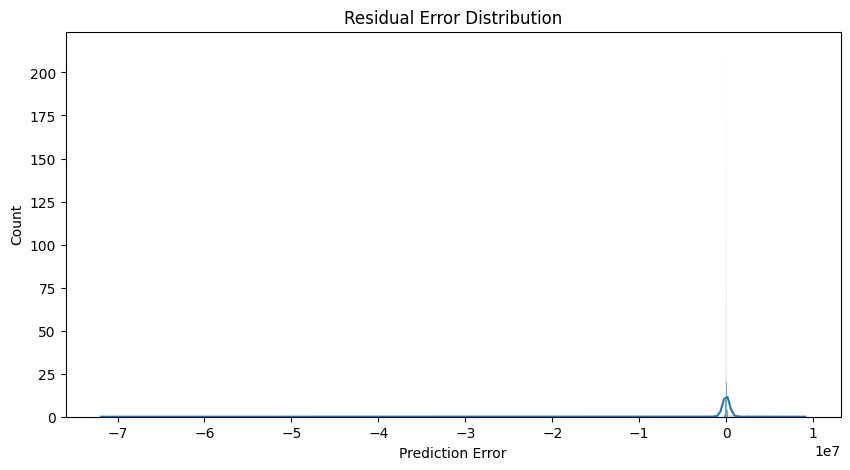

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Error Distribution")
plt.xlabel("Prediction Error")
plt.show()

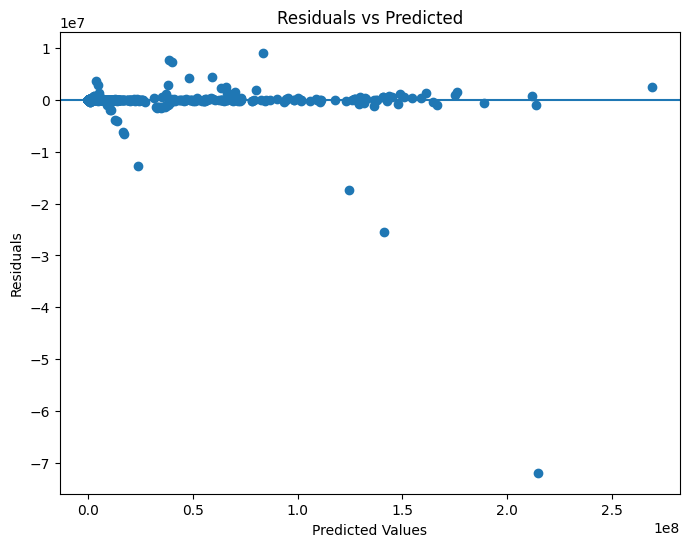

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(predictions, residuals)
plt.axhline(y=0)
plt.title("Residuals vs Predicted")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

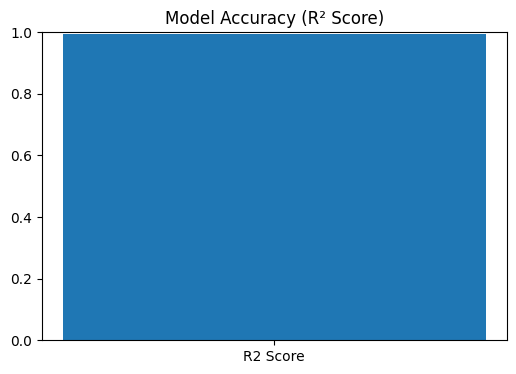

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)

plt.figure(figsize=(6,4))
plt.bar(["R2 Score"], [r2])
plt.ylim(0,1)
plt.title("Model Accuracy (R² Score)")
plt.show()

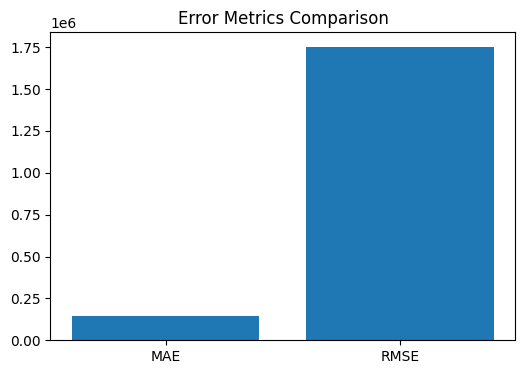

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

plt.figure(figsize=(6,4))
plt.bar(["MAE","RMSE"], [mae, rmse])
plt.title("Error Metrics Comparison")
plt.show()

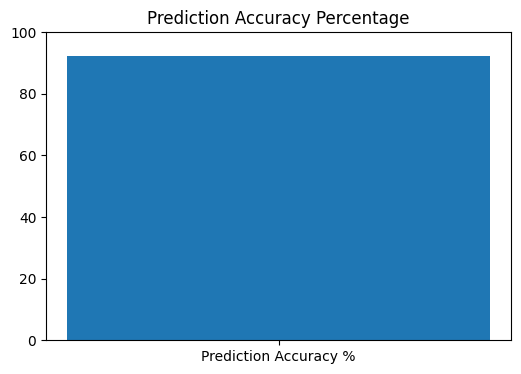

np.float64(92.30468508866731)

In [ ]:
accuracy_percent = 100 - (np.mean(np.abs(residuals / y_test.values)) * 100)

plt.figure(figsize=(6,4))
plt.bar(["Prediction Accuracy %"], [accuracy_percent])
plt.ylim(0,100)
plt.title("Prediction Accuracy Percentage")
plt.show()

accuracy_percent

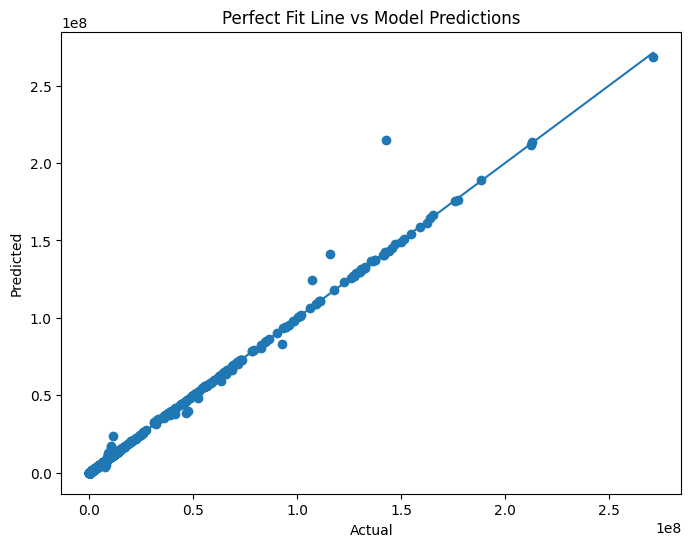

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.title("Perfect Fit Line vs Model Predictions")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

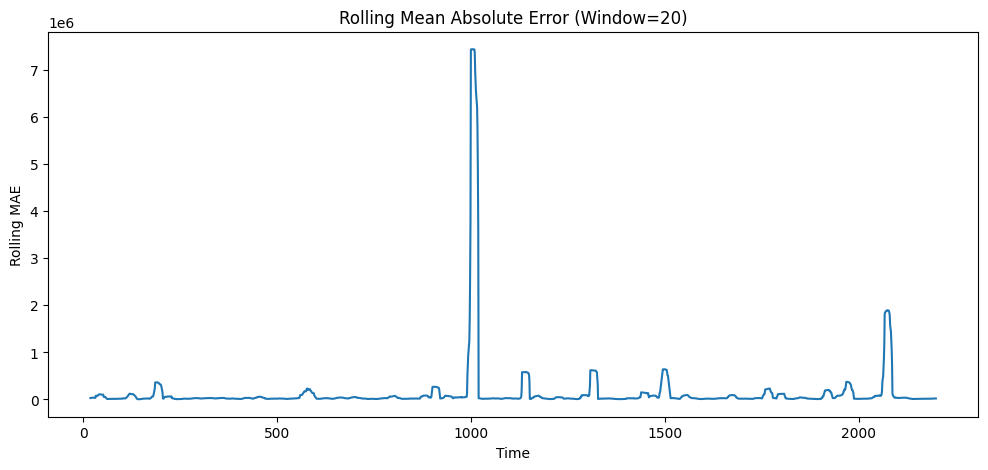

In [ ]:
rolling_error = pd.Series(np.abs(residuals)).rolling(window=20).mean()

plt.figure(figsize=(12,5))
plt.plot(rolling_error)
plt.title("Rolling Mean Absolute Error (Window=20)")
plt.xlabel("Time")
plt.ylabel("Rolling MAE")
plt.show()

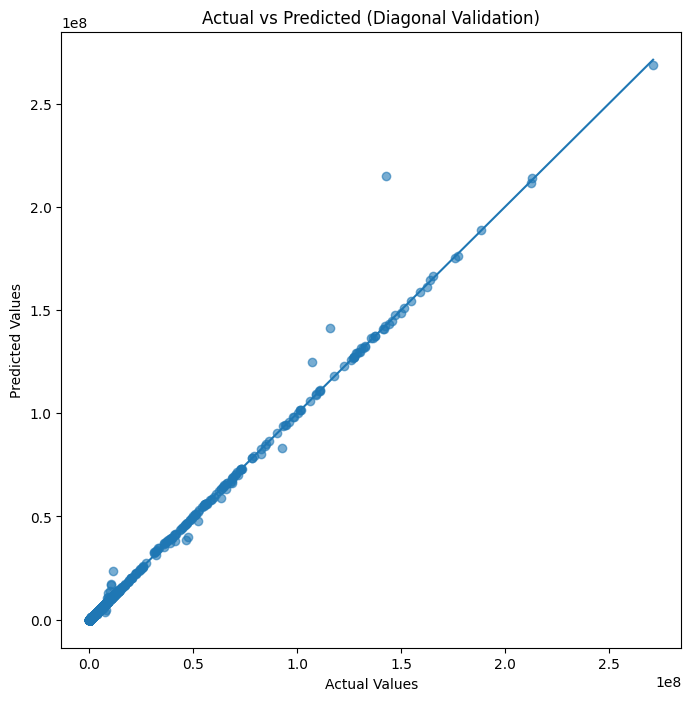

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,8))

plt.scatter(y_test, predictions, alpha=0.6)

min_val = min(min(y_test), min(predictions))
max_val = max(max(y_test), max(predictions))

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Diagonal Validation)")
plt.show()

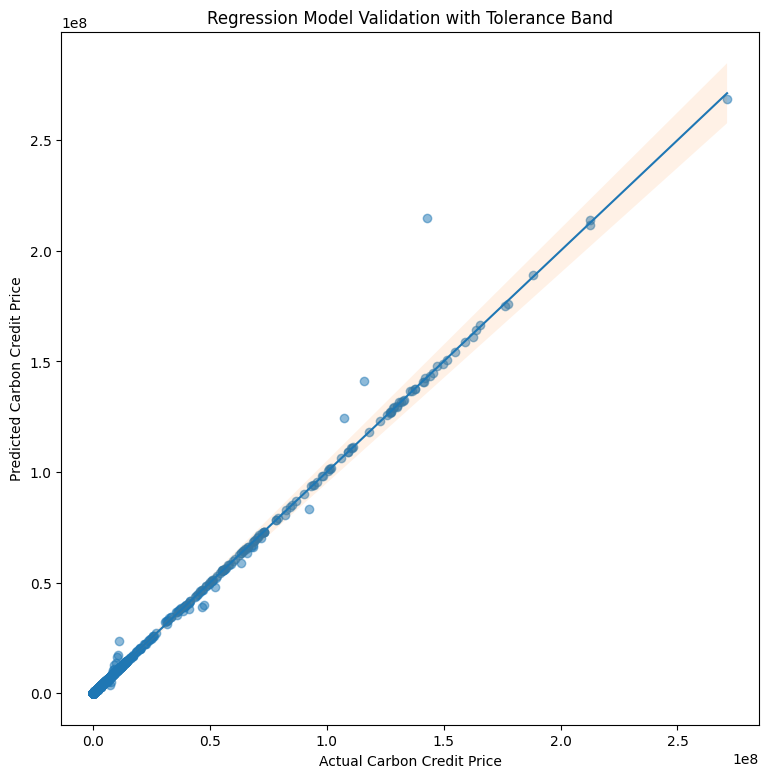

In [ ]:
plt.figure(figsize=(9,9))

plt.scatter(y_test, predictions, alpha=0.5)

plt.plot([min_val, max_val], [min_val, max_val])

plt.fill_between([min_val, max_val],
                 [min_val*0.95, max_val*0.95],
                 [min_val*1.05, max_val*1.05],
                 alpha=0.1)

plt.xlabel("Actual Carbon Credit Price")
plt.ylabel("Predicted Carbon Credit Price")
plt.title("Regression Model Validation with Tolerance Band")
plt.show()

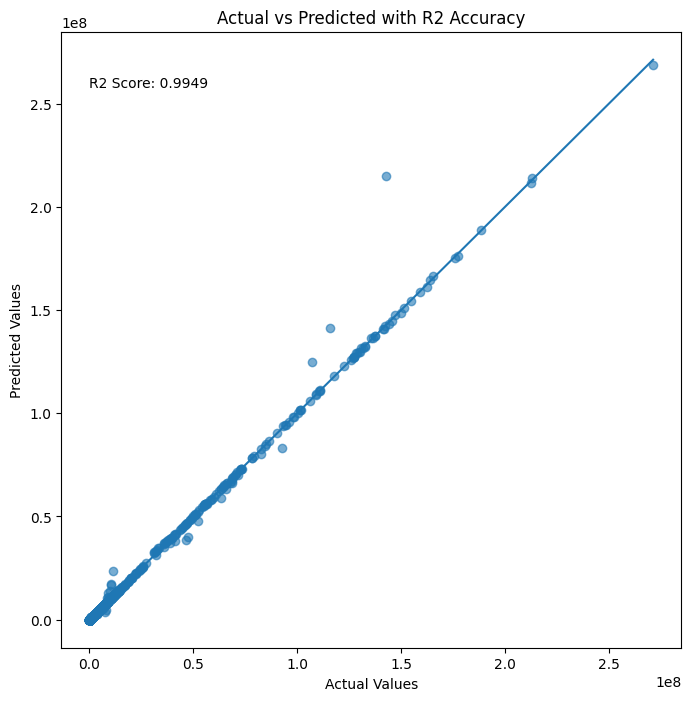

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)

plt.figure(figsize=(8,8))

plt.scatter(y_test, predictions, alpha=0.6)

plt.plot([min_val, max_val], [min_val, max_val])

plt.text(min_val, max_val*0.95, "R2 Score: " + str(round(r2,4)))

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted with R2 Accuracy")
plt.show()

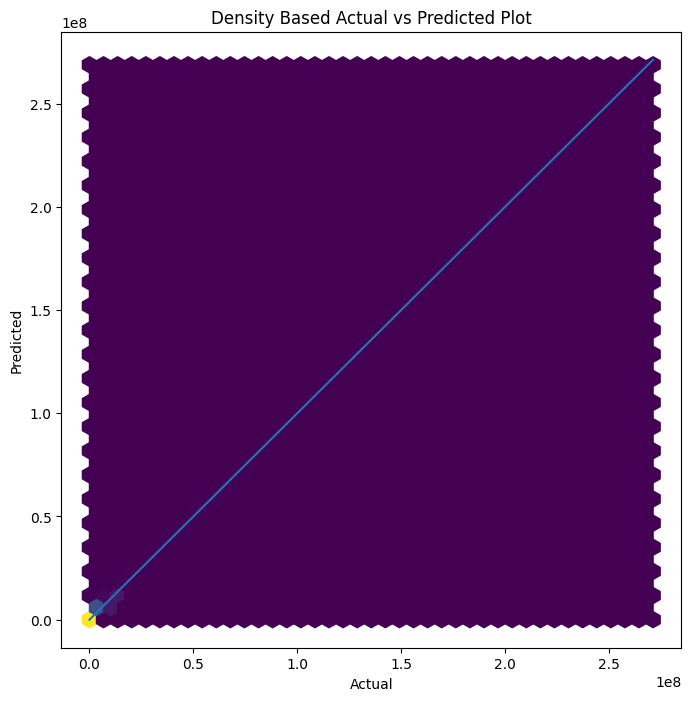

In [ ]:
plt.figure(figsize=(8,8))

plt.hexbin(y_test, predictions, gridsize=40)

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Density Based Actual vs Predicted Plot")
plt.show()

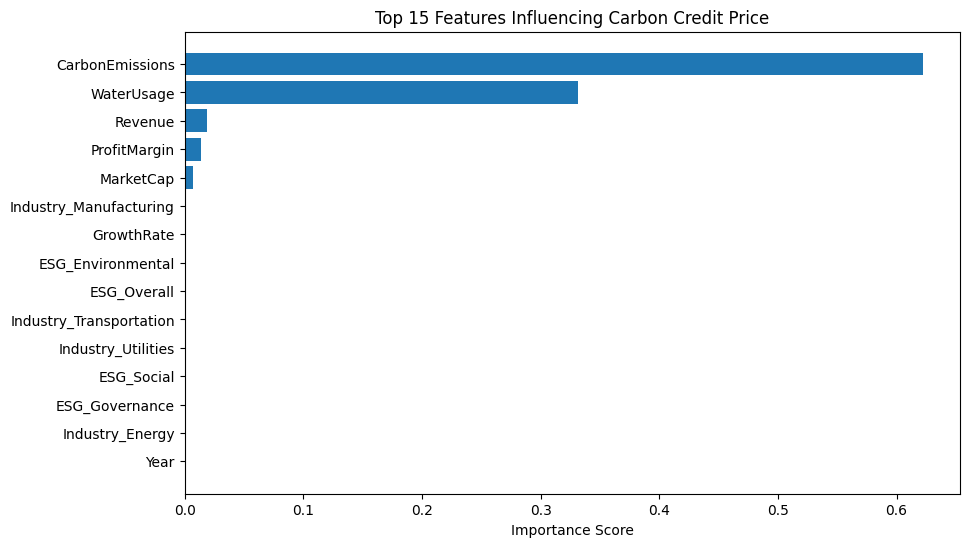

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

importance = model.feature_importances_
feature_names = X.columns

indices = np.argsort(importance)[-15:]

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importance[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.title("Top 15 Features Influencing Carbon Credit Price")
plt.xlabel("Importance Score")
plt.show()

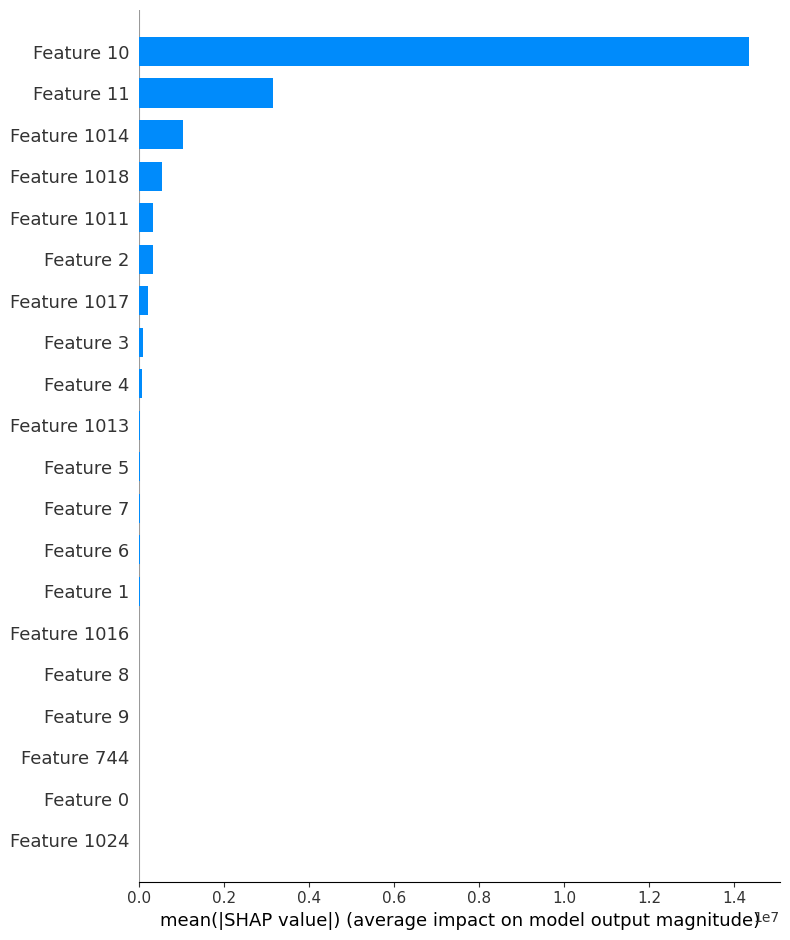

In [ ]:
!pip install shap
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train, plot_type="bar")

In [ ]:
!pip install optuna xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 20.6 MB/s eta 0:00:00


In [ ]:
import optuna
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import numpy as np

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

if file_name.endswith(".xlsx"):
    df = pd.read_excel(file_name)
elif file_name.endswith(".csv"):
    df = pd.read_csv(file_name, low_memory=False)
else:
    raise ValueError("Unsupported file format")

print("Dataset Loaded Successfully")
print("Shape:", df.shape)
df.head()

Saving company_esg_financial_dataset (1).csv to company_esg_financial_dataset (1).csv
Dataset Loaded Successfully
Shape: (11000, 16)


,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

df = df.reset_index(drop=True)

numeric_cols = df.select_dtypes(include=np.number).columns

if len(numeric_cols) == 0:
    raise ValueError("No numeric column found for target")

target_column = numeric_cols[-1]

X = df.drop(columns=[target_column])
y = df[target_column]

X = pd.get_dummies(X, drop_first=True)

X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y_values = y.to_numpy()

print("Prepared Data Shapes:")
print("X_scaled:", X_scaled.shape)
print("y_values:", y_values.shape)

Prepared Data Shapes:
X_scaled: (11000, 1025)
y_values: (11000,)


In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=3)

print("TimeSeriesSplit Ready")

TimeSeriesSplit Ready


In [ ]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

def rf_objective(trial):

    model = RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 100, 300),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 8),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 4),
        random_state=42,
        n_jobs=-1
    )

    rmse_scores = []

    for train_idx, val_idx in tscv.split(X_scaled):
        X_train_cv = X_scaled[train_idx]
        X_val_cv = X_scaled[val_idx]
        y_train_cv = y_values[train_idx]
        y_val_cv = y_values[val_idx]

        model.fit(X_train_cv, y_train_cv)
        preds = model.predict(X_val_cv)

        rmse = np.sqrt(mean_squared_error(y_val_cv, preds))
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)

In [ ]:
rf_study = optuna.create_study(direction="minimize")
rf_study.optimize(rf_objective, n_trials=15)

best_params = rf_study.best_params

print("Best Parameters:", best_params)

[I 2026-02-24 09:02:32,282] A new study created in memory with name: no-name-cde3587d-9b47-4e5a-bdec-61675d9a9016
[I 2026-02-24 09:03:42,989] Trial 0 finished with value: 20288467.92273293 and parameters: {'n_estimators': 148, 'max_depth': 7, 'min_samples_split': 4, 'min_samples_leaf': 2}. Best is trial 0 with value: 20288467.92273293.
[I 2026-02-24 09:06:20,581] Trial 1 finished with value: 20216251.492253337 and parameters: {'n_estimators': 264, 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 2}. Best is trial 1 with value: 20216251.492253337.
[I 2026-02-24 09:08:08,353] Trial 2 finished with value: 21832592.13760619 and parameters: {'n_estimators': 235, 'max_depth': 7, 'min_samples_split': 3, 'min_samples_leaf': 4}. Best is trial 1 with value: 20216251.492253337.
[I 2026-02-24 09:08:54,002] Trial 3 finished with value: 21894821.690744508 and parameters: {'n_estimators': 122, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 4}. Best is trial 1 with value: 2021

Best Parameters: {'n_estimators': 156, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1}


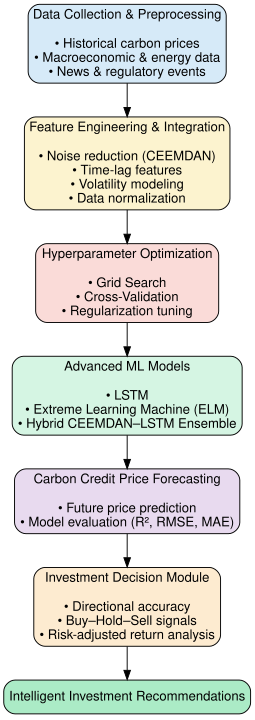

In [ ]:
# Install Graphviz
!apt-get -qq install graphviz
!pip install -q graphviz

from graphviz import Digraph

# Create flowchart
flow = Digraph(format='png')
flow.attr(rankdir='TB', size='8,10')
flow.attr('node', shape='box', style='rounded,filled', fontname='Helvetica')

# Nodes
flow.node('A', 'Data Collection & Preprocessing\n\n• Historical carbon prices\n• Macroeconomic & energy data\n• News & regulatory events', fillcolor='#D6EAF8')

flow.node('B', 'Feature Engineering & Integration\n\n• Noise reduction (CEEMDAN)\n• Time-lag features\n• Volatility modeling\n• Data normalization', fillcolor='#FCF3CF')

flow.node('C', 'Hyperparameter Optimization\n\n• Grid Search\n• Cross-Validation\n• Regularization tuning', fillcolor='#FADBD8')

flow.node('D', 'Advanced ML Models\n\n• LSTM\n• Extreme Learning Machine (ELM)\n• Hybrid CEEMDAN–LSTM Ensemble', fillcolor='#D5F5E3')

flow.node('E', 'Carbon Credit Price Forecasting\n\n• Future price prediction\n• Model evaluation (R², RMSE, MAE)', fillcolor='#E8DAEF')

flow.node('F', 'Investment Decision Module\n\n• Directional accuracy\n• Buy–Hold–Sell signals\n• Risk-adjusted return analysis', fillcolor='#FDEBD0')

flow.node('G', 'Intelligent Investment Recommendations', fillcolor='#ABEBC6')

# Edges
flow.edges([
    ('A','B'),
    ('B','C'),
    ('C','D'),
    ('D','E'),
    ('E','F'),
    ('F','G')
])

# Display
flow

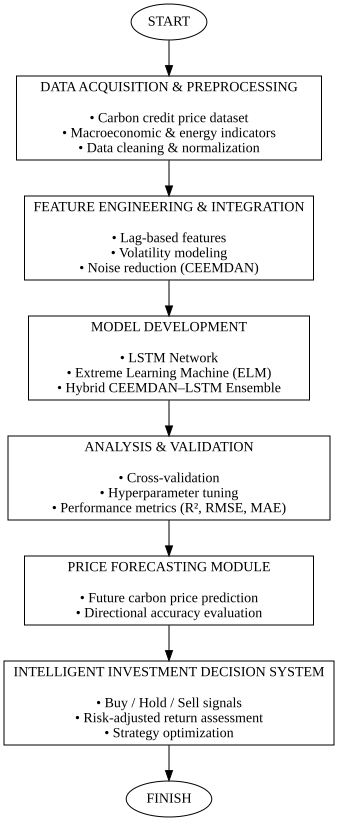

In [ ]:
# Install Graphviz (Run once)
!apt-get -qq install graphviz
!pip install -q graphviz

from graphviz import Digraph

flow = Digraph(format='png')
flow.attr(rankdir='TB')
flow.attr('node', shape='rectangle', fontname='Times New Roman')

# Nodes
flow.node('Start', 'START', shape='oval')

flow.node('Data',
          'DATA ACQUISITION & PREPROCESSING\n\n'
          '• Carbon credit price dataset\n'
          '• Macroeconomic & energy indicators\n'
          '• Data cleaning & normalization')

flow.node('Feature',
          'FEATURE ENGINEERING & INTEGRATION\n\n'
          '• Lag-based features\n'
          '• Volatility modeling\n'
          '• Noise reduction (CEEMDAN)')

flow.node('Model',
          'MODEL DEVELOPMENT\n\n'
          '• LSTM Network\n'
          '• Extreme Learning Machine (ELM)\n'
          '• Hybrid CEEMDAN–LSTM Ensemble')

flow.node('Validation',
          'ANALYSIS & VALIDATION\n\n'
          '• Cross-validation\n'
          '• Hyperparameter tuning\n'
          '• Performance metrics (R², RMSE, MAE)')

flow.node('Forecast',
          'PRICE FORECASTING MODULE\n\n'
          '• Future carbon price prediction\n'
          '• Directional accuracy evaluation')

flow.node('Decision',
          'INTELLIGENT INVESTMENT DECISION SYSTEM\n\n'
          '• Buy / Hold / Sell signals\n'
          '• Risk-adjusted return assessment\n'
          '• Strategy optimization')

flow.node('End', 'FINISH', shape='oval')

# Flow connections
flow.edges([
    ('Start','Data'),
    ('Data','Feature'),
    ('Feature','Model'),
    ('Model','Validation'),
    ('Validation','Forecast'),
    ('Forecast','Decision'),
    ('Decision','End')
])

flow

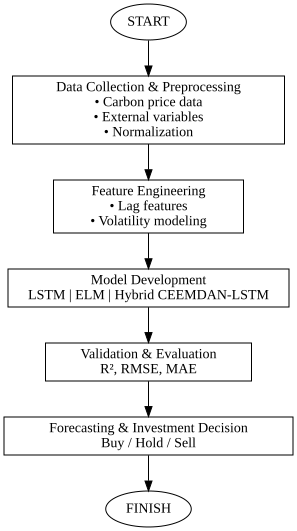

In [ ]:
# Install graphviz (run once)
!apt-get -qq install graphviz
!pip install -q graphviz

from graphviz import Digraph

flow = Digraph(format='png')
flow.attr(rankdir='TB')
flow.attr('node', shape='rectangle', fontname='Times New Roman')

# Nodes
flow.node('Start', 'START', shape='oval')

flow.node('Data',
          'Data Collection & Preprocessing\n'
          '• Carbon price data\n'
          '• External variables\n'
          '• Normalization')

flow.node('Feature',
          'Feature Engineering\n'
          '• Lag features\n'
          '• Volatility modeling')

flow.node('Model',
          'Model Development\n'
          'LSTM | ELM | Hybrid CEEMDAN-LSTM')

flow.node('Eval',
          'Validation & Evaluation\n'
          'R², RMSE, MAE')

flow.node('Decision',
          'Forecasting & Investment Decision\n'
          'Buy / Hold / Sell')

flow.node('End', 'FINISH', shape='oval')

# Flow
flow.edges([
    ('Start','Data'),
    ('Data','Feature'),
    ('Feature','Model'),
    ('Model','Eval'),
    ('Eval','Decision'),
    ('Decision','End')
])

flow

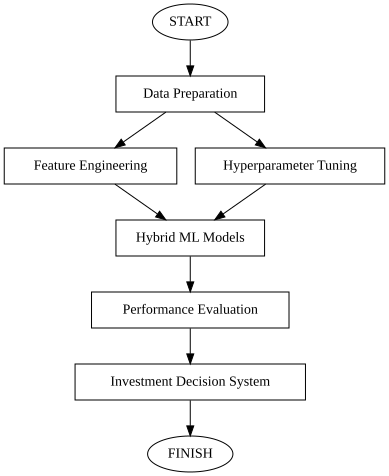

In [ ]:
from graphviz import Digraph

flow = Digraph(format='png')
flow.attr(rankdir='TB')
flow.attr('node', shape='rectangle', fontname='Times New Roman')

flow.node('Start','START', shape='oval')

flow.node('Data','Data Preparation')

flow.node('Feat','Feature Engineering')
flow.node('Opt','Hyperparameter Tuning')

flow.node('Model','Hybrid ML Models')
flow.node('Eval','Performance Evaluation')
flow.node('Decision','Investment Decision System')

flow.node('End','FINISH', shape='oval')

flow.edges([
    ('Start','Data'),
    ('Data','Feat'),
    ('Data','Opt'),
    ('Feat','Model'),
    ('Opt','Model'),
    ('Model','Eval'),
    ('Eval','Decision'),
    ('Decision','End')
])

flow

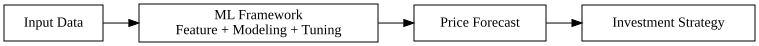

In [ ]:
from graphviz import Digraph

flow = Digraph(format='png')
flow.attr(rankdir='LR')
flow.attr('node', shape='rectangle', fontname='Times New Roman')

flow.node('Input','Input Data')
flow.node('Process','ML Framework\nFeature + Modeling + Tuning')
flow.node('Output','Price Forecast')
flow.node('Decision','Investment Strategy')

flow.edges([
    ('Input','Process'),
    ('Process','Output'),
    ('Output','Decision')
])

flow

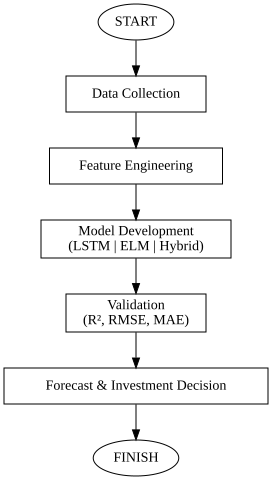

In [ ]:
!apt-get -qq install graphviz
!pip install -q graphviz

from graphviz import Digraph

flow = Digraph(format='png')
flow.attr(rankdir='TB')
flow.attr('node', shape='rectangle', fontname='Times New Roman')

flow.node('A','START', shape='oval')
flow.node('B','Data Collection')
flow.node('C','Feature Engineering')
flow.node('D','Model Development\n(LSTM | ELM | Hybrid)')
flow.node('E','Validation\n(R², RMSE, MAE)')
flow.node('F','Forecast & Investment Decision')
flow.node('G','FINISH', shape='oval')

flow.edges([('A','B'),('B','C'),('C','D'),('D','E'),('E','F'),('F','G')])

flow

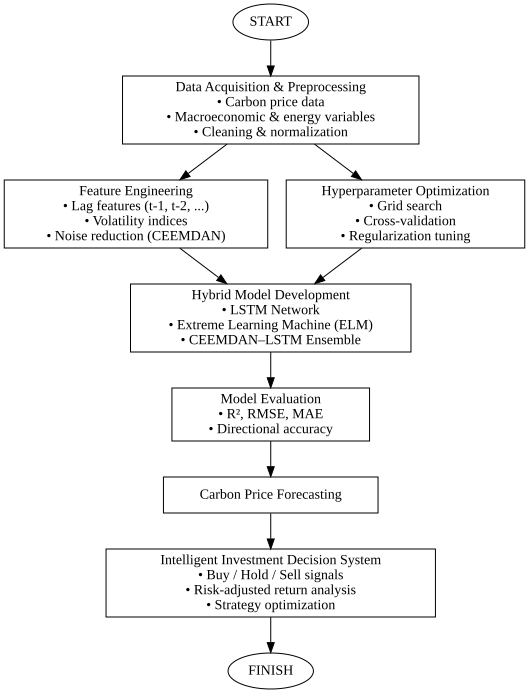

In [ ]:
# Install graphviz (Run once in Colab)
!apt-get -qq install graphviz
!pip install -q graphviz

from graphviz import Digraph

flow = Digraph(format='png')
flow.attr(rankdir='TB')
flow.attr('node', shape='rectangle', fontname='Times New Roman')

# Start
flow.node('Start','START', shape='oval')

# Data Stage
flow.node('Data',
          'Data Acquisition & Preprocessing\n'
          '• Carbon price data\n'
          '• Macroeconomic & energy variables\n'
          '• Cleaning & normalization')

# Parallel Branch 1 – Feature Engineering
flow.node('Feature',
          'Feature Engineering\n'
          '• Lag features (t-1, t-2, ...)\n'
          '• Volatility indices\n'
          '• Noise reduction (CEEMDAN)')

# Parallel Branch 2 – Optimization
flow.node('Optimize',
          'Hyperparameter Optimization\n'
          '• Grid search\n'
          '• Cross-validation\n'
          '• Regularization tuning')

# Model Development
flow.node('Model',
          'Hybrid Model Development\n'
          '• LSTM Network\n'
          '• Extreme Learning Machine (ELM)\n'
          '• CEEMDAN–LSTM Ensemble')

# Evaluation
flow.node('Evaluation',
          'Model Evaluation\n'
          '• R², RMSE, MAE\n'
          '• Directional accuracy')

# Forecasting
flow.node('Forecast',
          'Carbon Price Forecasting')

# Decision Module
flow.node('Decision',
          'Intelligent Investment Decision System\n'
          '• Buy / Hold / Sell signals\n'
          '• Risk-adjusted return analysis\n'
          '• Strategy optimization')

# End
flow.node('End','FINISH', shape='oval')

# Connections
flow.edges([
    ('Start','Data'),
    ('Data','Feature'),
    ('Data','Optimize'),
    ('Feature','Model'),
    ('Optimize','Model'),
    ('Model','Evaluation'),
    ('Evaluation','Forecast'),
    ('Forecast','Decision'),
    ('Decision','End')
])

flow

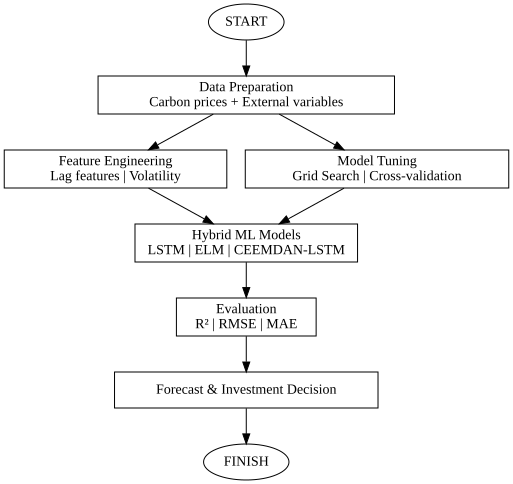

In [ ]:
# Install graphviz (run once)
!apt-get -qq install graphviz
!pip install -q graphviz

from graphviz import Digraph

flow = Digraph(format='png')
flow.attr(rankdir='TB')
flow.attr('node', shape='rectangle', fontname='Times New Roman')

# Nodes
flow.node('Start','START', shape='oval')

flow.node('Data',
          'Data Preparation\n'
          'Carbon prices + External variables')

flow.node('Feature',
          'Feature Engineering\n'
          'Lag features | Volatility')

flow.node('Tune',
          'Model Tuning\n'
          'Grid Search | Cross-validation')

flow.node('Model',
          'Hybrid ML Models\n'
          'LSTM | ELM | CEEMDAN-LSTM')

flow.node('Eval',
          'Evaluation\n'
          'R² | RMSE | MAE')

flow.node('Decision',
          'Forecast & Investment Decision')

flow.node('End','FINISH', shape='oval')

# Connections
flow.edges([
    ('Start','Data'),
    ('Data','Feature'),
    ('Data','Tune'),
    ('Feature','Model'),
    ('Tune','Model'),
    ('Model','Eval'),
    ('Eval','Decision'),
    ('Decision','End')
])

flow